In [2]:
import tensorflow as tf

print("--- GPU VERIFICATION ---")
print(f"TensorFlow version: {tf.__version__}")

# Check if TF sees the GPU
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ SUCCESS! Found {len(gpu_devices)} GPU(s):")
    for gpu in gpu_devices:
        print(f"  -> {gpu}")
    print("\nYour GTX 1650 is ready for training!")
else:
    print("❌ FAILED: No GPU detected. We might need to restart the VS Code window.")

--- GPU VERIFICATION ---
TensorFlow version: 2.10.1
✅ SUCCESS! Found 1 GPU(s):
  -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Your GTX 1650 is ready for training!


In [1]:
import tensorflow as tf
import numpy as np

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

# Final GPU test
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
NumPy version: 1.26.4
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import os

# Update this to your local folder path!
dataset_path = r"D:\00" 

if os.path.exists(dataset_path):
    classes = os.listdir(dataset_path)
    print(f"Dataset found at: {dataset_path}")
    print(f"Number of classes: {len(classes)}")
    for cls in classes:
        count = len(os.listdir(os.path.join(dataset_path, cls)))
        print(f" - {cls}: {count} images")
else:
    print("Path not found. Please double-check the folder location.")

Dataset found at: D:\00
Number of classes: 15
 - potato_bacteria: 569 images
 - potato_early_blight: 502 images
 - potato_fungi: 700 images
 - potato_healthy: 647 images
 - potato_late_blight: 289 images
 - rice_blast: 828 images
 - rice_brown_spot: 424 images
 - rice_healthy: 250 images
 - rice_sheath_blight: 500 images
 - rice_tungro_virus: 239 images
 - wheat_black_point: 303 images
 - wheat_blast: 400 images
 - wheat_fusarium_foot_rot: 250 images
 - wheat_healthy: 250 images
 - wheat_leaf_blight: 400 images


In [3]:
import splitfolders
import os

# 1. SETUP
input_folder = r"D:\00"
output_folder = r"D:\00_Final_Split" # Creating a new folder to be safe

# 2. THE SPLIT STRATEGY
# We are using 80% Training, 10% Validation, 10% Testing.
# WHY? Because your smallest classes only have ~240 images.
# We need every extra image we can get in Training (80% gives us ~190 images).
# 10% for testing (~25 images) is tight, but necessary to keep training robust.

print("✂️ Splitting dataset... This ensures no 'Cheating' in your thesis results.")

splitfolders.ratio(
    input_folder, 
    output=output_folder, 
    seed=1337,           # Fixed seed so this split is reproducible
    ratio=(.8, .1, .1),  # 80% Train, 10% Val, 10% Test
    group_prefix=None, 
    move=False           # We COPY files, not move them (safer)
)

print(f"✅ Done! Your organized data is in: {output_folder}")
print("You should see 'train', 'val', and 'test' folders there now.")

✂️ Splitting dataset... This ensures no 'Cheating' in your thesis results.
✅ Done! Your organized data is in: D:\00_Final_Split
You should see 'train', 'val', and 'test' folders there now.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# --- 1. CONFIGURATION ---
DATA_DIR = r"D:\00_Final_Split"
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Kept small for GTX 1650 stability

# --- 2. GPU MEMORY GROWTH (Crucial for Laptops) ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Ready: {len(gpus)} device(s) active.")
    except RuntimeError as e:
        print(e)

# --- 3. DATA LOADERS ---
print("\nLoading Data...")
# Augmentation for Training (Helps with small classes)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for Validation (Just rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 4. AUTO-CALCULATE CLASS WEIGHTS ---
# We calculate this fresh every time to be 100% sure
print("\n⚖️ Computing Class Weights...")
cls_train = train_generator.classes
classes = np.unique(cls_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=cls_train)
class_weights_dict = dict(zip(classes, weights))
print("Weights ready.")

# --- 5. BUILD MODEL (DenseNet121) ---
print("\n🏗️ Building DenseNet121...")
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base initially (Phase 1)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)  # Stabilizes the training
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)          # Prevents overfitting
predictions = Dense(15, activation='softmax')(x) # 15 Classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- 6. CALLBACKS (The Safety Net) ---
checkpoint = ModelCheckpoint(
    r"D:\00_Final_Split\best_thesis_model.keras", 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# Stop if not improving for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Slow down learning rate if stuck (Helps reach 90%)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# --- 7. TRAIN ---
print("\n🚀 STARTING TRAINING (Phase 1)...")
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training Complete. Check the 'best_thesis_model.keras' file.")

✅ GPU Ready: 1 device(s) active.

Loading Data...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.

⚖️ Computing Class Weights...
Weights ready.

🏗️ Building DenseNet121...
29084464/29084464 [==============================] - 19s 1us/step

🚀 STARTING TRAINING (Phase 1)...
Epoch 1/30
328/328 [==============================] - ETA: 0s - loss: 0.6266 - accuracy: 0.7709
Epoch 1: val_accuracy improved from -inf to 0.85692, saving model to D:\00_Final_Split\best_thesis_model.keras
328/328 [==============================] - 156s 412ms/step - loss: 0.6266 - accuracy: 0.7709 - val_loss: 0.3652 - val_accuracy: 0.8569 - lr: 0.0010
Epoch 2/30
328/328 [==============================] - ETA: 0s - loss: 0.3440 - accuracy: 0.8580
Epoch 2: val_accuracy improved from 0.85692 to 0.90000, saving model to D:\00_Final_Split\best_thesis_model.keras
328/328 [==============================] - 91s 278ms/step - loss: 0.3440 - accuracy: 0.8580 - val_loss: 0.2663 - val_accuracy:

In [5]:
# --- STEP 4: THE FINAL THESIS EXAM ---
# Run this ONLY after training is 100% finished.

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os

# 1. Load the Best Saved Model
# (This ensures we use the best version, not just the last epoch)
print("Loading best model...")
model_path = r"D:\00_Final_Split\best_thesis_model.keras"
model = load_model(model_path)

# 2. Prepare the Test Data (The 10% held back)
TEST_DIR = r"D:\00_Final_Split\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # IMPORTANT: Do not shuffle, or labels will be mixed up!
)

# 3. Run the Evaluation
print("\n📝 Running Final Evaluation on Test Set...")
results = model.evaluate(test_generator)
print(f"\n🏆 FINAL THESIS ACCURACY: {results[1]*100:.2f}%")

# 4. Generate the Detailed Report (Precision/Recall/F1-Score)
# This is what you need for your thesis "Results" chapter.
print("\n📊 Generating Detailed Report...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

Loading best model...
Found 663 images belonging to 15 classes.

📝 Running Final Evaluation on Test Set...
42/42 [==============================] - 15s 308ms/step - loss: 0.1237 - accuracy: 0.9593

🏆 FINAL THESIS ACCURACY: 95.93%

📊 Generating Detailed Report...
42/42 [==============================] - 8s 139ms/step
                         precision    recall  f1-score   support

        potato_bacteria       0.97      0.97      0.97        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.96      0.93      0.94        70
         potato_healthy       0.96      0.98      0.97        66
     potato_late_blight       1.00      1.00      1.00        30
             rice_blast       0.94      0.88      0.91        84
        rice_brown_spot       0.87      0.93      0.90        43
           rice_healthy       0.96      0.96      0.96        25
     rice_sheath_blight       0.96      0.94      0.95        50
      rice_tungro_virus       0

✅ Model Saved Safe and Sound.
✅ Class Labels Saved (We need this for the App).
✅ Confusion Matrix Image Saved.


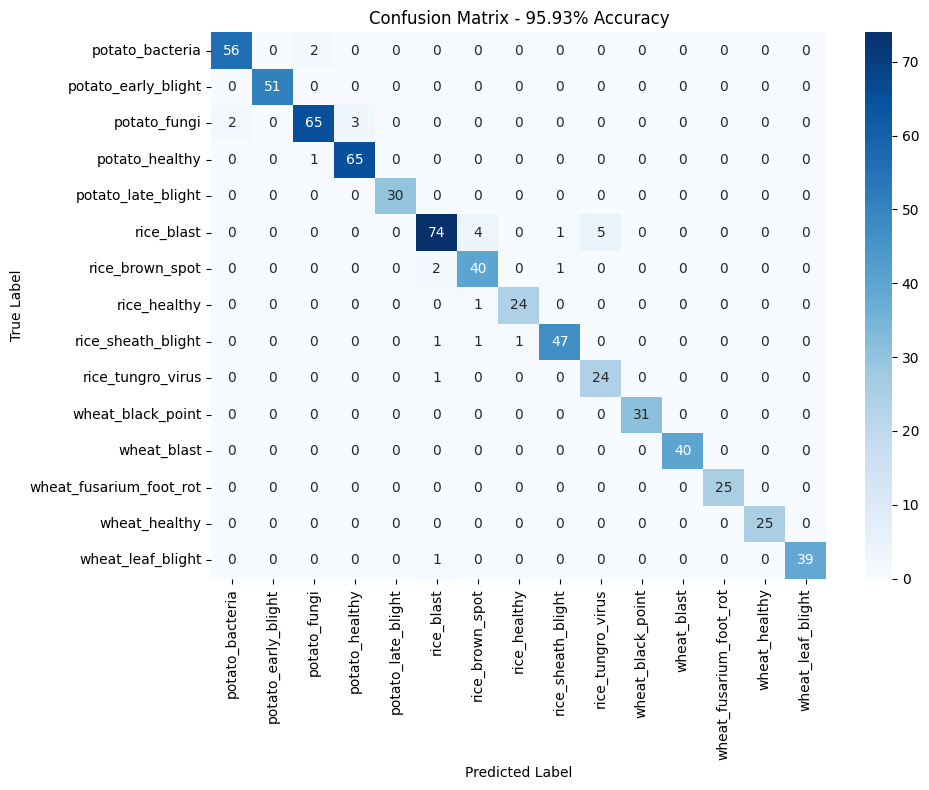

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. SAVE THE FINAL MODEL (Just in case)
model.save(r"D:\00_Final_Split\Final_96_Accuracy_Model.keras")
print("✅ Model Saved Safe and Sound.")

# 2. SAVE THE CLASS NAMES (Crucial for the Android App)
# We need to know that '0' = 'potato_bacteria', etc.
class_indices = train_generator.class_indices
with open(r"D:\00_Final_Split\class_indices.json", 'w') as f:
    json.dump(class_indices, f)
print("✅ Class Labels Saved (We need this for the App).")

# 3. GENERATE & SAVE THE CONFUSION MATRIX (For your Thesis Paper)
# This creates the cool red/blue chart showing where the model made mistakes
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - 95.93% Accuracy')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r"D:\00_Final_Split\confusion_matrix.png")
print("✅ Confusion Matrix Image Saved.")
plt.show()

In [7]:
import tensorflow as tf

# 1. Load your 96% model
model_path = r"D:\00_Final_Split\Final_96_Accuracy_Model.keras"
model = tf.keras.models.load_model(model_path)

# 2. Convert it to Android Format (TFLite)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # This shrinks the file size!
tflite_model = converter.convert()

# 3. Save the .tflite file
tflite_path = r"D:\00_Final_Split\crop_disease_model.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Android Model Saved: {tflite_path}")
print("You can now drag and drop this file into Android Studio!")

INFO:tensorflow:Assets written to: C:\Users\shiha\AppData\Local\Temp\tmpe7xvy4aw\assets


INFO:tensorflow:Assets written to: C:\Users\shiha\AppData\Local\Temp\tmpe7xvy4aw\assets


✅ Android Model Saved: D:\00_Final_Split\crop_disease_model.tflite
You can now drag and drop this file into Android Studio!
